In [1]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt

from tensorflow.keras.utils import (
    image_dataset_from_directory,
    load_img,
    img_to_array
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    Rescaling
)

from tensorflow.keras.applications import VGG16

c:\Users\AMD\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [8]:
import os

print(os.getcwd())

c:\Users\AMD\OneDrive\Desktop\DL_AU\marvel


In [9]:
from tensorflow.keras.utils import image_dataset_from_directory

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

dataset_path = r"C:\Users\AMD\OneDrive\Desktop\DL_AU\marvel"

train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 12 files belonging to 4 classes.


Using 10 files for training.
Found 12 files belonging to 4 classes.
Using 2 files for validation.


In [10]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(images.dtype)
    print(labels)

(10, 224, 224, 3)
<dtype: 'float32'>
tf.Tensor([0 2 0 1 3 3 0 1 2 3], shape=(10,), dtype=int32)


In [11]:
class_names = train_ds.class_names

print("\nClasses Found:")
print(class_names)



Classes Found:
['Captain America', 'Hulk', 'Iron Man', 'black_widow']


In [12]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2)
])

In [13]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 67s 1us/step


In [14]:
model = Sequential([
    data_augmentation,

    Rescaling(1./255),

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),

    Dropout(0.3),

    Dense(4, activation="softmax")
])

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.4000 - loss: 1.4744 - val_accuracy: 0.0000e+00 - val_loss: 1.6848
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2000 - loss: 1.3948 - val_accuracy: 0.0000e+00 - val_loss: 1.5633
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3000 - loss: 1.3676 - val_accuracy: 0.0000e+00 - val_loss: 1.4659
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3000 - loss: 1.2469 - val_accuracy: 0.5000 - val_loss: 1.4188
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2000 - loss: 1.3434 - val_accuracy: 0.5000 - val_loss: 1.3835
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4000 - loss: 1.2380 - val_accuracy: 0.5000 - val_loss: 1.3752
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4000 - loss: 1.2667 - val_accuracy: 0.5000 - val_loss: 1.3916
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2000 - loss: 1.3045 - val_accuracy: 0.5000 - val_loss: 1.4333
Epoc

['image10.jpeg', 'image11.jpeg', 'image12.jpeg']


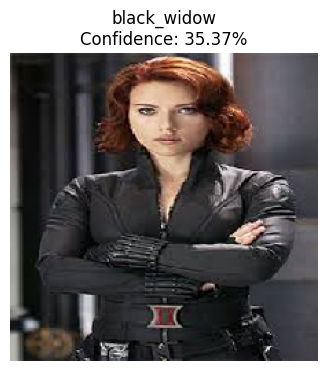

image10.jpeg -> black_widow (35.37%)


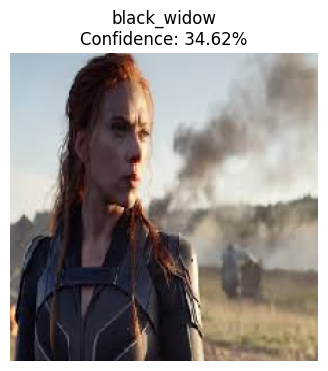

image11.jpeg -> black_widow (34.62%)


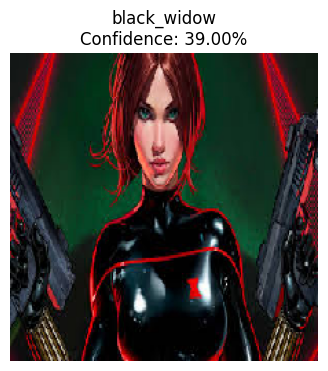

image12.jpeg -> black_widow (39.00%)


In [22]:
import os

test_folder = test_folder = r"C:\Users\AMD\OneDrive\Desktop\DL_AU\marvel\black_widow"

print(os.listdir(test_folder))

for image_name in os.listdir(test_folder):

    image_path = os.path.join(
        test_folder,
        image_name
    )

    img = load_img(
        image_path,
        target_size=(224,224)
    )

    img_array = img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    prediction = model.predict(
        img_array,
        verbose=0
    )

    predicted_class = class_names[
        np.argmax(prediction)
    ]

    confidence = np.max(prediction)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"{predicted_class}\nConfidence: {confidence*100:.2f}%"
    )

    plt.show()

    print(
        f"{image_name} -> {predicted_class} ({confidence*100:.2f}%)"
    )
    